In [77]:
%run "/home/nichettg/Codici/Laboratorio/moduli.py"

In [78]:
def nome (stringa):
    """
    Estrae il nome, cioè la frequenza, dal titolo di ogni file input letto
    """
    
    stringa_nuova = stringa.replace(f'./Data/Giorno{giorno}/tors_','').replace('.csv','').replace('h','H')
    return stringa_nuova

# 1. Raccolta Dati

In [79]:
giorno = 2

In [80]:
input_files = [f"./Data/Giorno{giorno}/{nome_file}" for nome_file in sorted(os.listdir(f'./Data/Giorno{giorno}'))]
dati= {}

for i, input_file in enumerate(input_files):
    letti = pd.read_csv(input_file)

    dati[nome(input_file)] = {
        "tempo": letti["Tempo"],
        "forzante": letti["Forzante"],
        "pendolo" : letti["Pendolo"],
        "ampiezza" : letti["Ampiezza"],
        "fase" : letti["Fase"],
    }

In [81]:
gf.display_dizionario(dati)

# 2. Analisi Oscillazione Forzata

## 2.1 Grafici Confronto Oscillazione

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


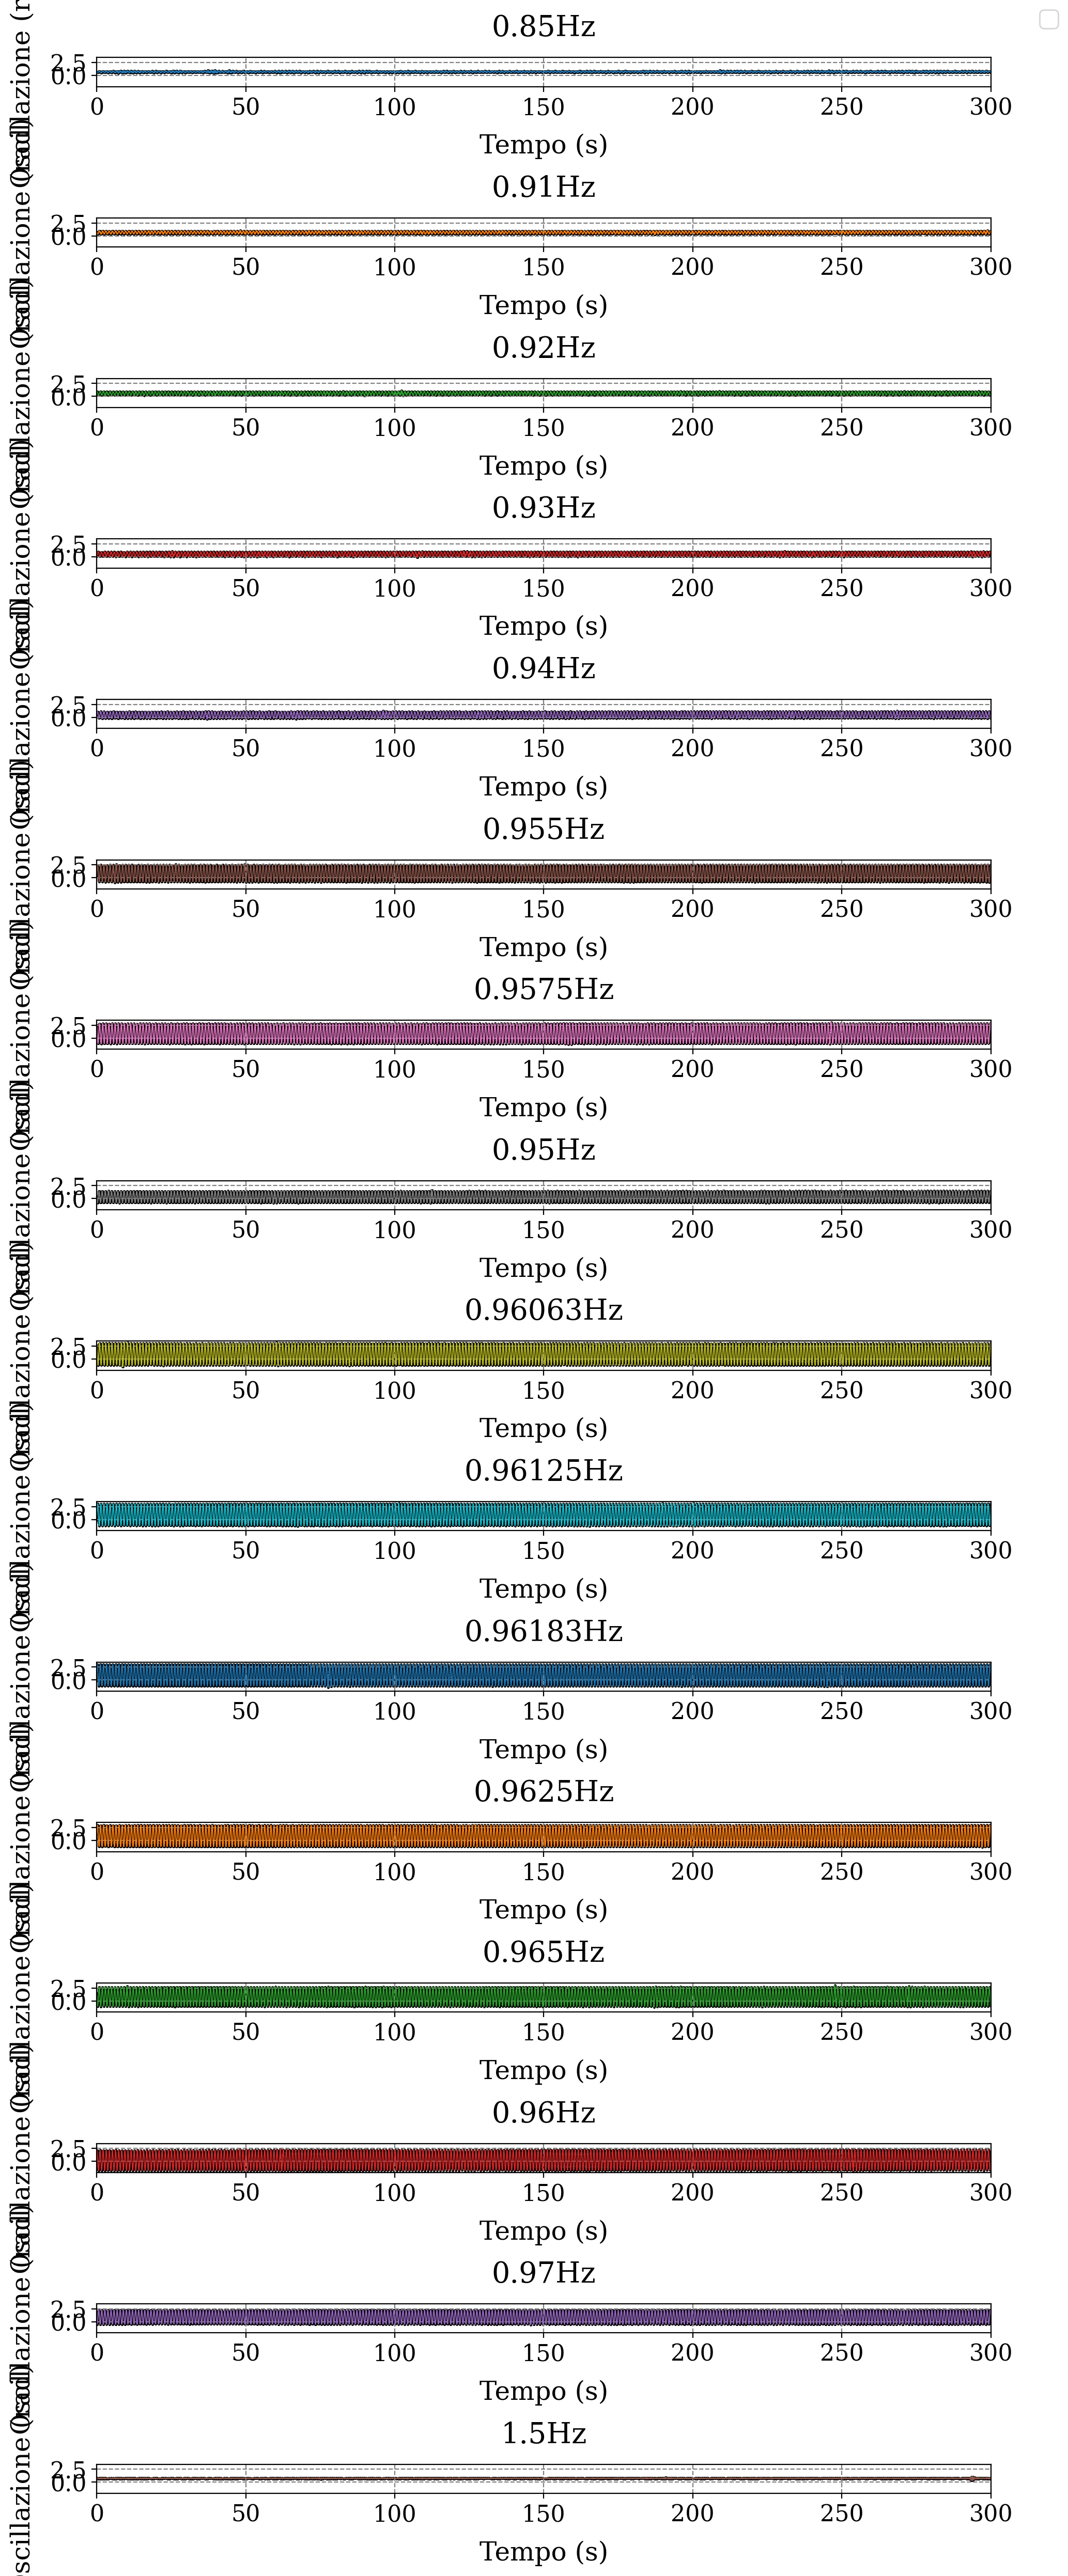

In [82]:
fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):

    ax = axes[i]

    titolo = nome(input_file)
    colore = next(color_cycle)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] * (2*np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")
    ax.set_xlim(0,300)
gf.salva_grafico(fig, "./Images/ConfrontoForzanti.pdf")

## 2.2 Calcolo Ampiezze Oscillazione

Raggio dell'intorno rispetto al quale i valori salvati sono i massimi. Di tali valori verrà poi calcolata la media, considerata come ampiezza media.

In [83]:
grafico_controllo = True

Vengono trovati massimi e minimi delle oscillazioni, viene poi fatta la media dei minimi e dei massimi singolarmente per poi fare la media tra i due. Vengono supposti gaussiani il campione dei massimi e quello dei minimi, considerando poi come ampiezza di oscillazione la media tra i due.

Serie 0.85Hz: 172 massimi e 183 minimi trovati 
 Periodo = 1.18 s 
 Intorno = 58
Serie 0.91Hz: 187 massimi e 201 minimi trovati 
 Periodo = 1.10 s 
 Intorno = 54
Serie 0.92Hz: 203 massimi e 193 minimi trovati 
 Periodo = 1.09 s 
 Intorno = 54
Serie 0.93Hz: 200 massimi e 211 minimi trovati 
 Periodo = 1.08 s 
 Intorno = 52
Serie 0.94Hz: 231 massimi e 222 minimi trovati 
 Periodo = 1.06 s 
 Intorno = 52
Serie 0.955Hz: 244 massimi e 263 minimi trovati 
 Periodo = 1.05 s 
 Intorno = 52
Serie 0.9575Hz: 258 massimi e 265 minimi trovati 
 Periodo = 1.04 s 
 Intorno = 52
Serie 0.95Hz: 259 massimi e 263 minimi trovati 
 Periodo = 1.05 s 
 Intorno = 52
Serie 0.96063Hz: 254 massimi e 239 minimi trovati 
 Periodo = 1.04 s 
 Intorno = 52
Serie 0.96125Hz: 266 massimi e 257 minimi trovati 
 Periodo = 1.04 s 
 Intorno = 52
Serie 0.96183Hz: 237 massimi e 238 minimi trovati 
 Periodo = 1.04 s 
 Intorno = 50
Serie 0.9625Hz: 246 massimi e 246 minimi trovati 
 Periodo = 1.04 s 
 Intorno = 50
Serie 0.965Hz:

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


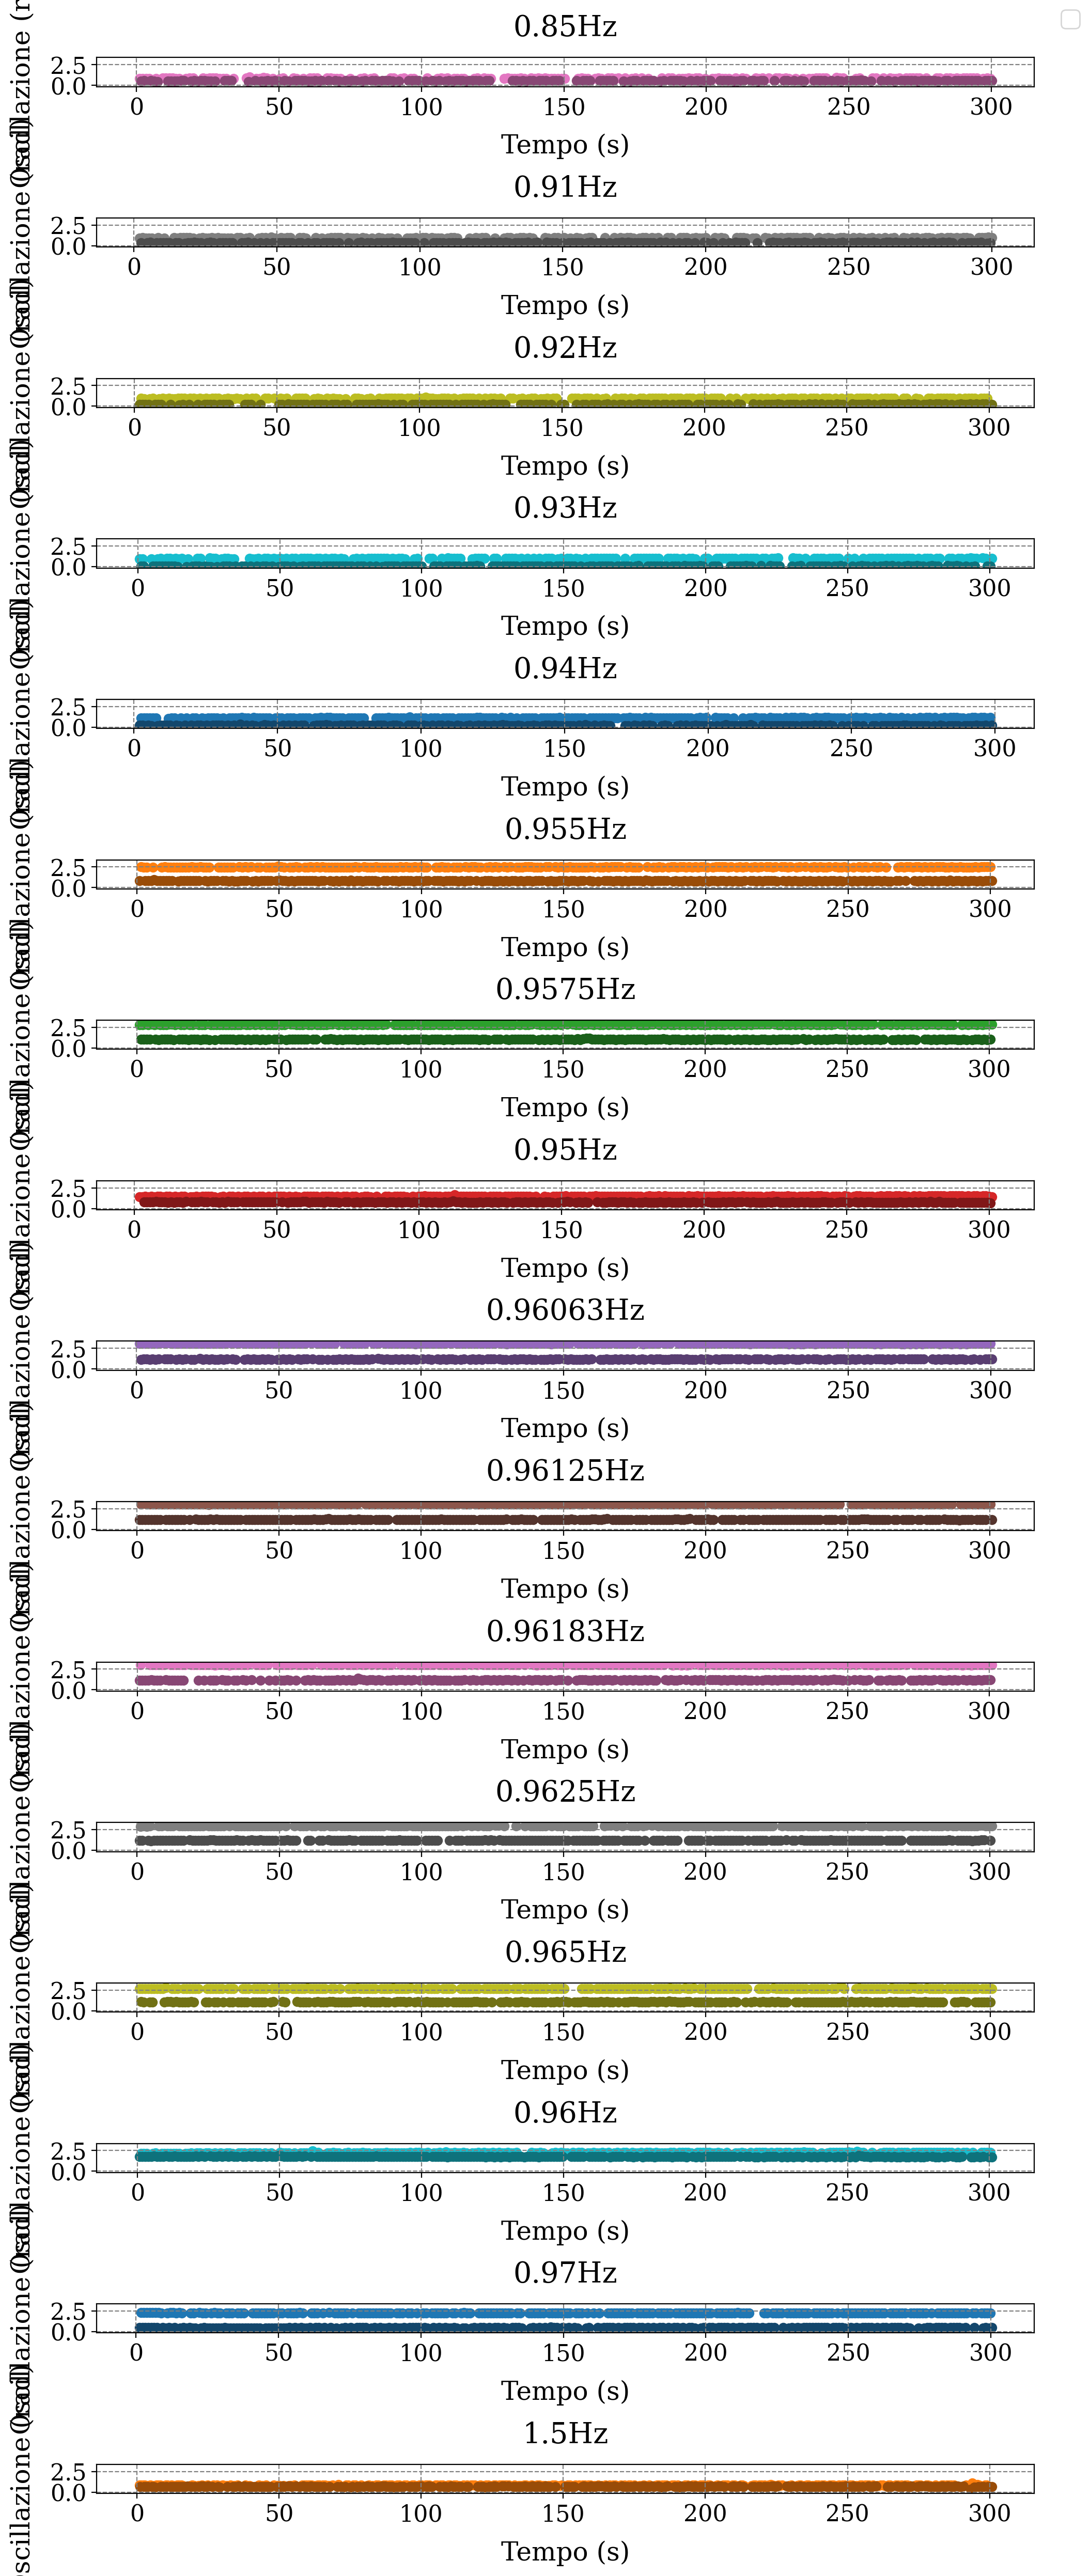

In [84]:
ampiezze = {}

if grafico_controllo: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati.keys()):
    valori = dati[serie]["pendolo"] * (2*np.pi)
    tempi = dati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = int((periodo / 2) * 50)

    fine_forzante = np.argmin(abs(dati[titolo]["forzante"]))

    for j, val in enumerate(valori):
        if j > fine_forzante:
            break
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        # Massimi
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])
        # Minimi
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(abs(val))
            minimi_t.append(tempi[j])

    ampiezze[serie] = (np.mean(massimi) + np.mean(minimi)) / 2

    print(f"Serie {serie}: {len(massimi)} massimi e {len(minimi)} minimi trovati \n Periodo = {periodo:.2f} s \n Intorno = {2 * raggio}")
    
    if grafico_controllo:
        ax = axes[i]
        colore = next(color_cycle)
        ax.scatter(massimi_t, massimi, color=colore)
        ax.scatter(minimi_t, minimi, color=gf.darken(colore))
        gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Oscillazione (rad)")

if grafico_controllo: gf.salva_grafico(fig, f"./Images/ConfrontoMassimi.pdf")

In [85]:
gf.display_dizionario(ampiezze)

0.85Hz,0.7082587691736812
0.91Hz,0.6691455277839934
0.92Hz,0.5897437116498407
0.93Hz,0.5285702839348351
0.94Hz,0.6569670475090482
0.955Hz,1.6486604549559212
0.9575Hz,1.9405920171372766
0.95Hz,1.1190790070300292
0.96063Hz,2.118269743733865
0.96125Hz,2.120778990563073
0.96183Hz,2.10469096692458


## 2.3 Fit Lorentziano

---

$$
L(x) = \frac{A}{(B + x^2)^2 + C x^2}
$$

dove:

- ( $A$ ): costante di scala, legata all'altezza del picco  
- ( $B = \omega_0^2$ ): frequenza di risonanza, corrisponde alla posizione del picco  
- ( $C = \gamma^2$ ): larghezza a metà altezza (HWHM), legata allo smorzamento del sistema

$$
L(x) = \frac{A}{(\omega_0^2 + x^2)^2 + \gamma^2 x^2}
$$

---

Seleziona se eseguire o no il fit lorentziano.

In [86]:
fit_lorentziano = True

Fit lorentziano:

A: $(17.5 \pm 5.7) \times 10^{-2}$

B: $(-144.4 \pm 3.1) \times 10^{-2}$

C: $(-18.4 \pm 4.3) \times 10^{-2}$

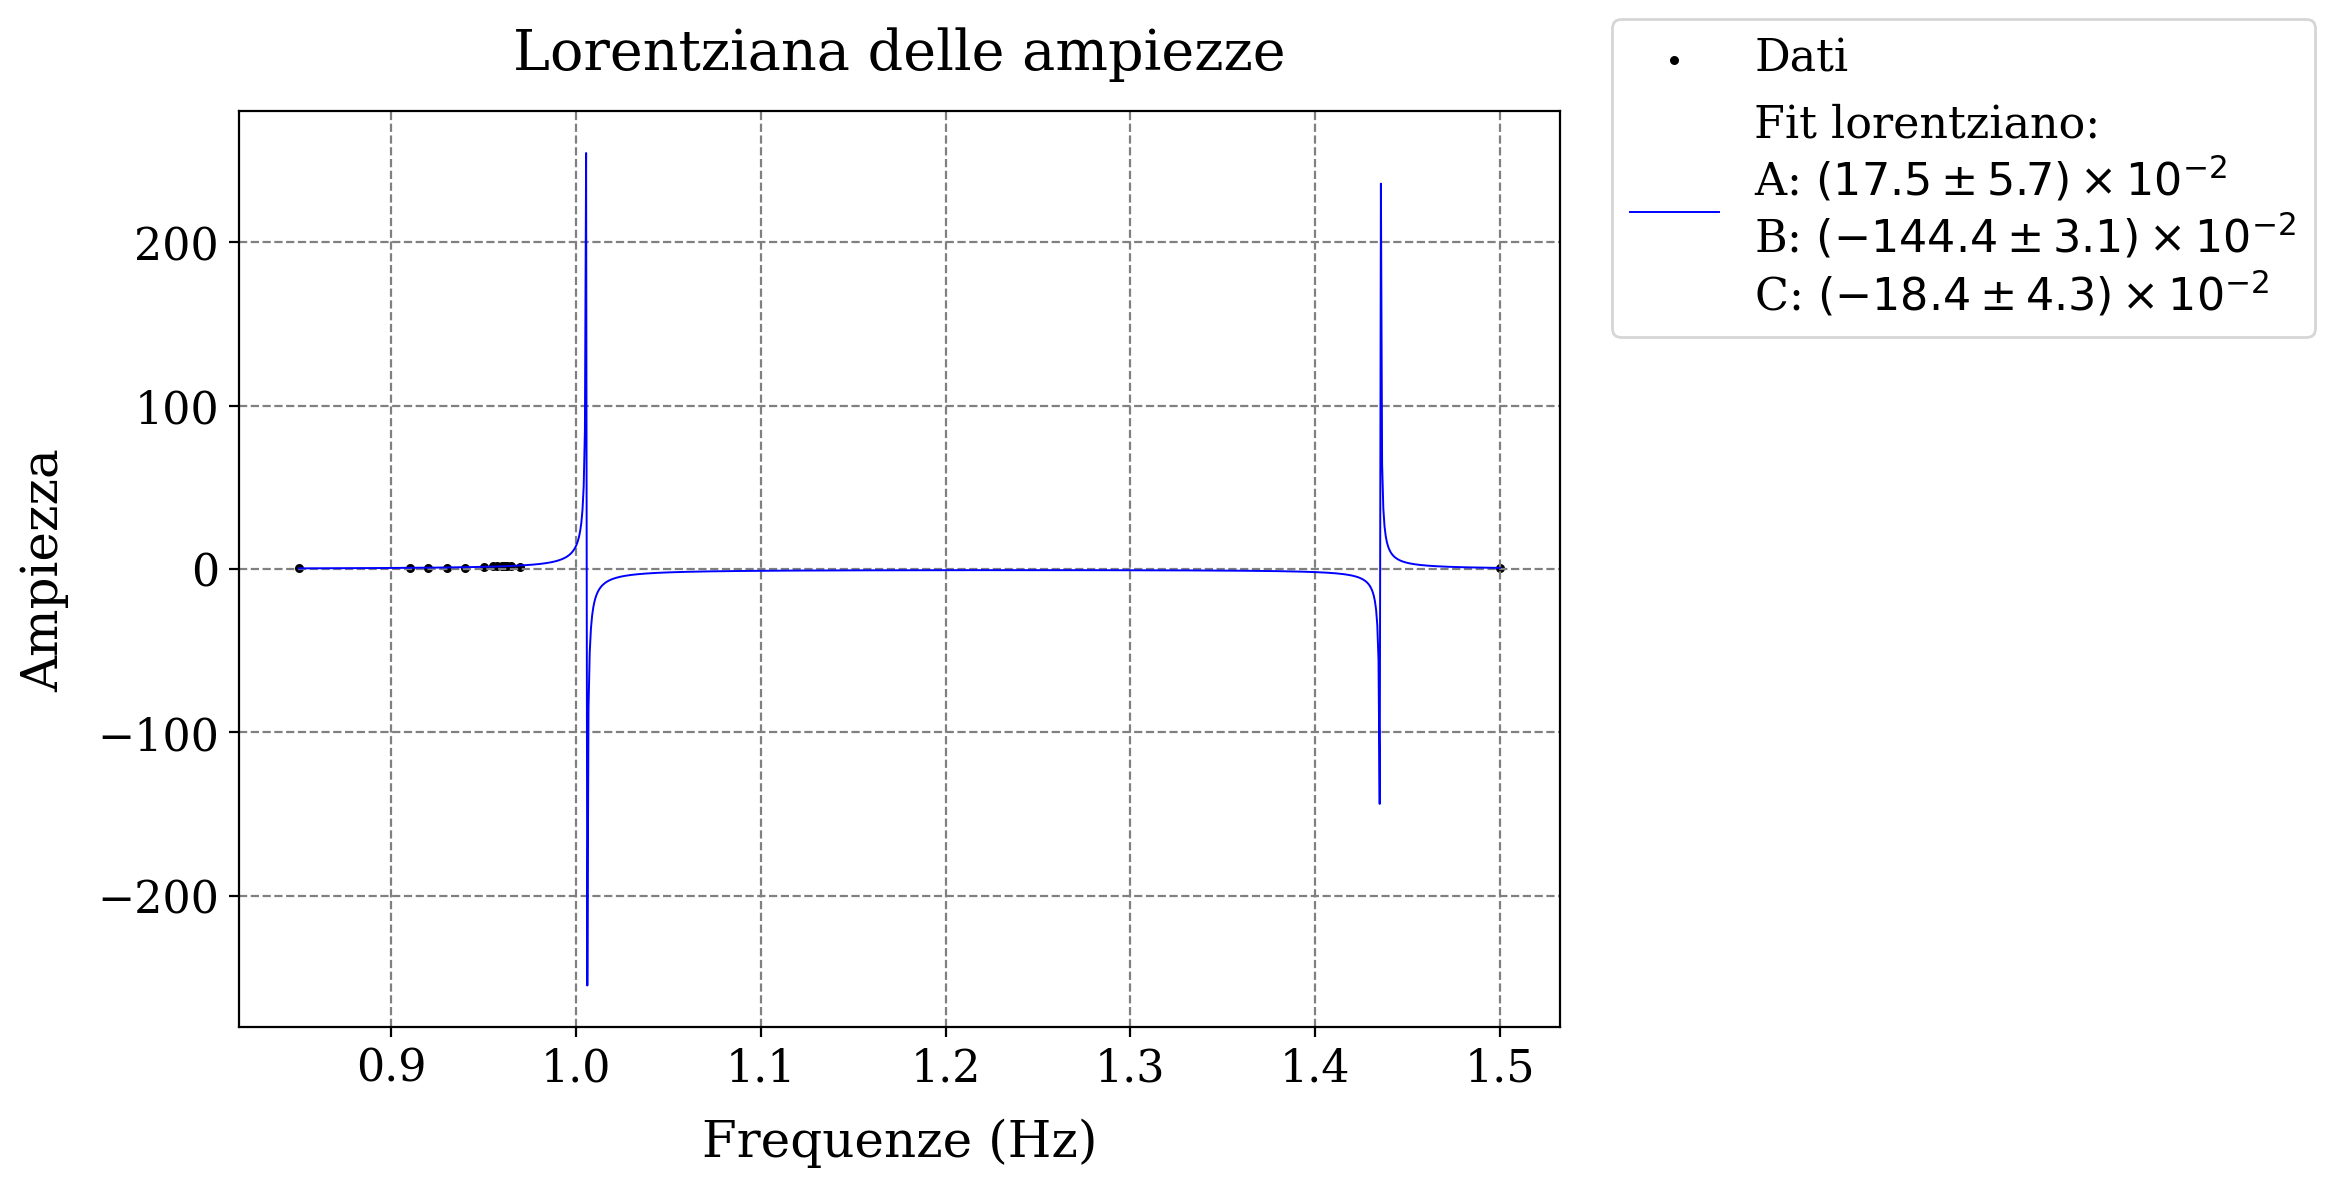

In [87]:
from scipy.optimize import curve_fit
from IPython.display import display, Markdown

def lorentziana(x, A, B, C):
    return A / ((x**2 + B)**2 + C * x**2)

frequenze = [float(key.replace('Hz', '')) for key in dati.keys()]
ampiezze_valori = list(ampiezze.values())

fig, ax = plt.subplots()
ax.scatter(frequenze, ampiezze_valori, color='black', label='Dati', s=5)

if fit_lorentziano:

    A0 = max(ampiezze_valori)
    B0 = np.mean(frequenze)**2
    C0 = 10

    p0 = [A0, B0, C0]
    popt, pcov = curve_fit(
        lorentziana,
        frequenze,
        ampiezze_valori,
        p0=p0
    )
    perr = np.sqrt(np.diag(pcov))

    label = [
        "Fit lorentziano:",
        rf"A: {gf.formatta_errore(popt[0], perr[0])}",
        rf"B: {gf.formatta_errore(popt[1], perr[1])}",
        rf"C: {gf.formatta_errore(popt[2], perr[2])}",
    ]

    x_fit = np.linspace(min(frequenze), max(frequenze), 1000)
    y_fit = lorentziana(x_fit, *popt)
    ax.plot(x_fit, y_fit, color='blue', linewidth=0.7, label='\n'.join(label))

    display(Markdown('\n\n'.join(label)))

gf.parametri_grafico(ax, "Lorentziana delle ampiezze", "Frequenze (Hz)", "Ampiezza")
gf.salva_grafico(fig, "./Images/Lorentziana.pdf")

# 3. Analisi Oscillazione Smorzata

## 3.1 Grafici Confronto Oscillazione

Tempo in cui vengono tagliati i dati.

In [88]:
fine = 400

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


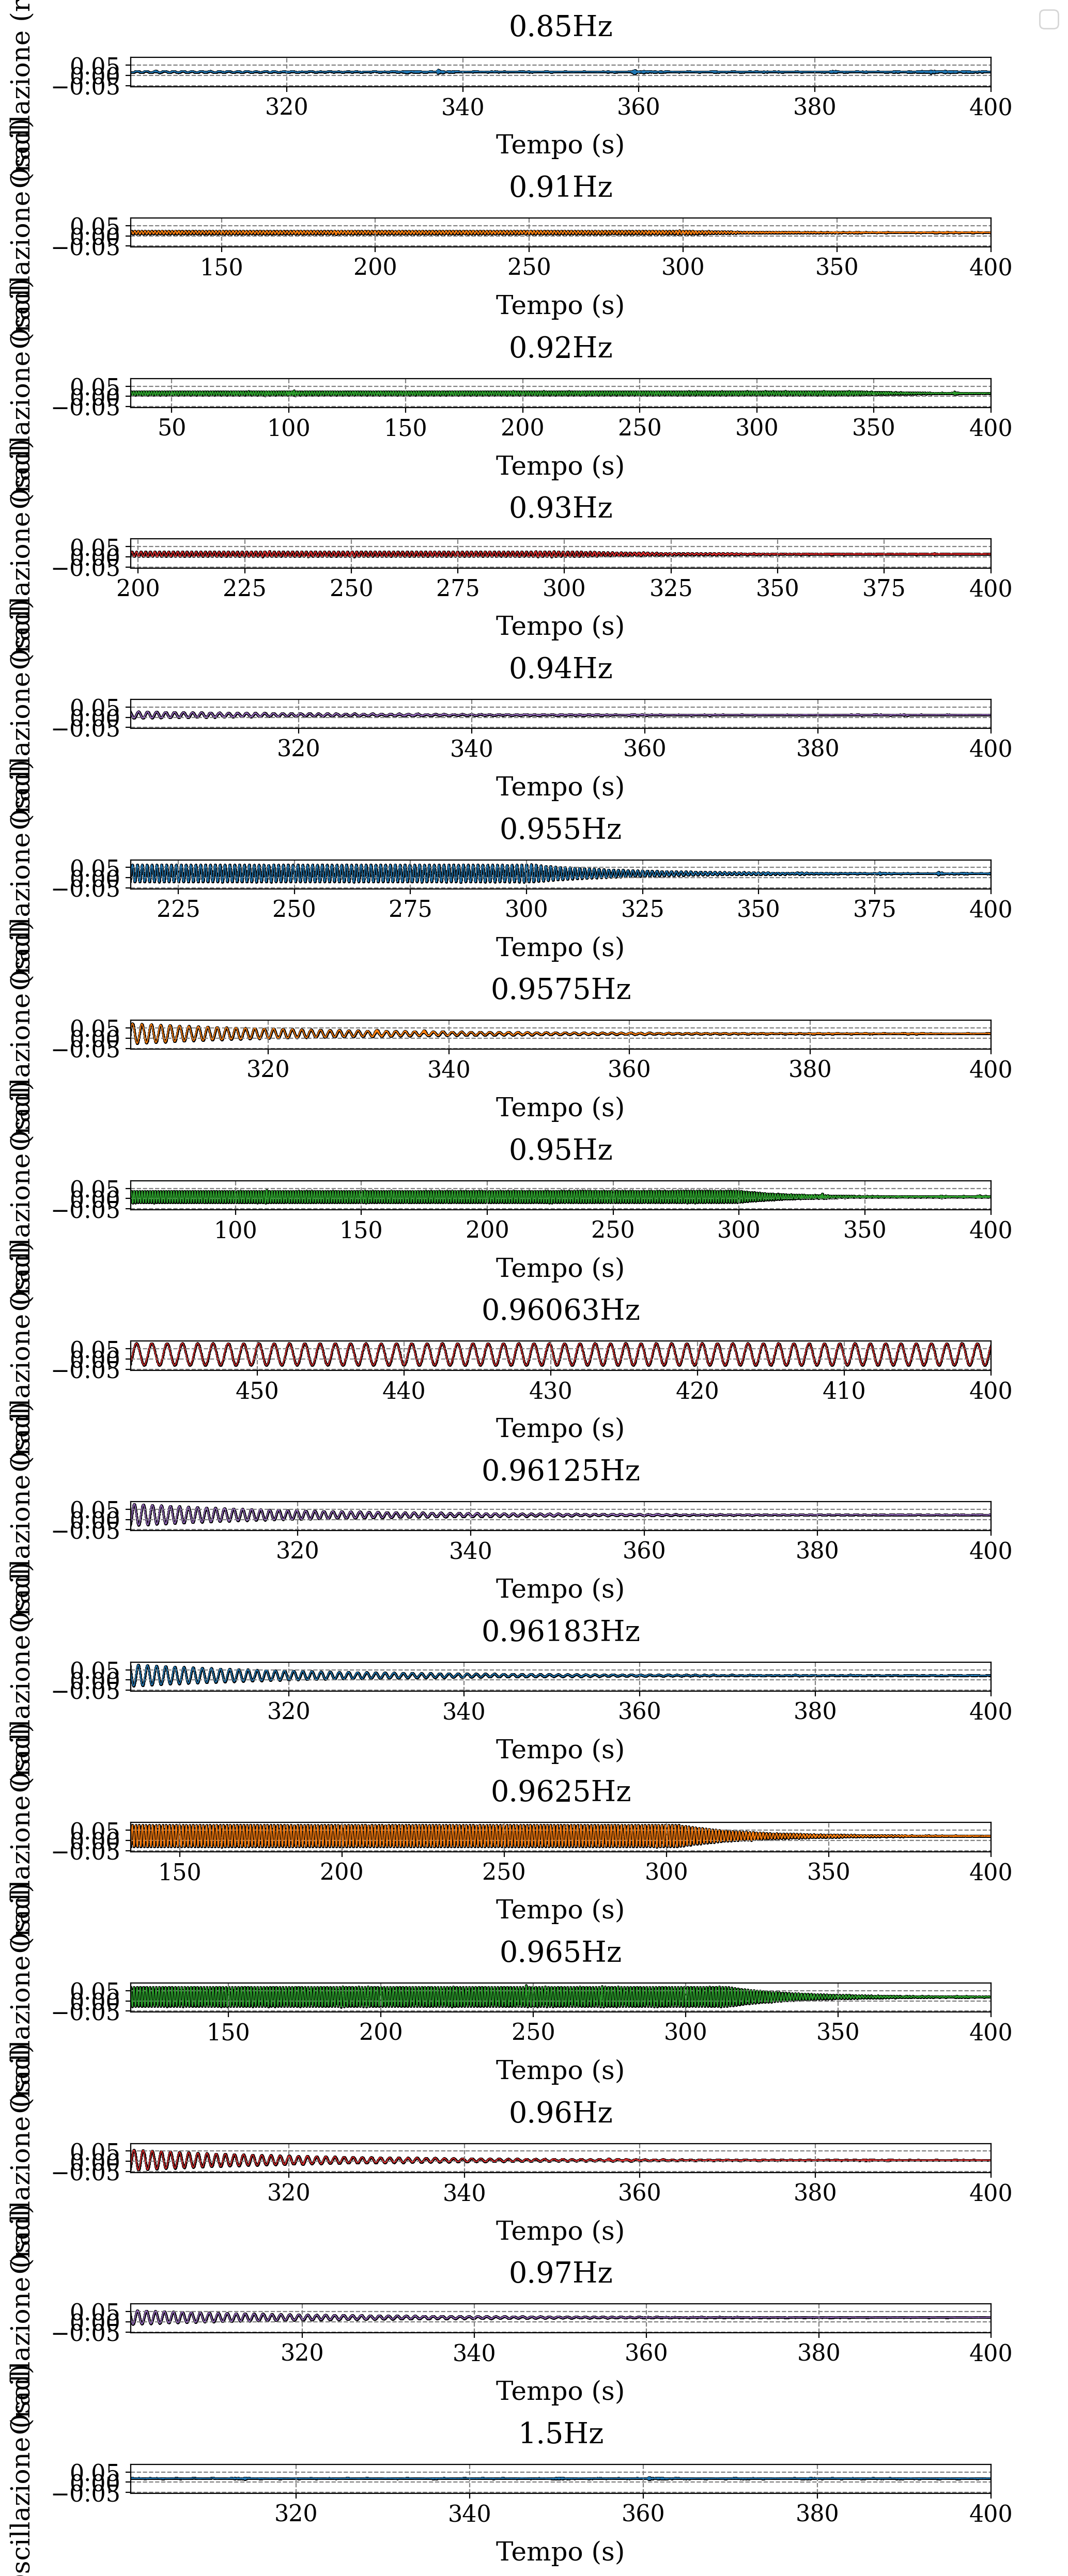

In [89]:
dati_tagliati = {}
fig, axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, input_file in enumerate(input_files):
    ax = axes[i]
    
    titolo = nome(input_file)
    colore = next(color_cycle_fisso)

    x = dati[titolo]["tempo"]
    y = dati[titolo]["pendolo"] / (2 * np.pi)

    ax.plot(x, y, color=colore, linewidth=0.7)
    ax.scatter(x, y, color="black", s=0.5)

    gf.parametri_grafico(ax, titolo, "Tempo (s)", "Oscillazione (rad)")

    # Calcolo indice di fine oscillazione forzante (inizio smorzamento)
    fine_forzante = np.argmin(np.abs(dati[titolo]["forzante"]))
    fine_taglio = np.searchsorted(dati[titolo]["tempo"], fine)

    ax.set_xlim(x[fine_forzante], x[fine_taglio])

    # Taglio i dati SOLO per la serie corrente
    dati_tagliati[titolo] = {
        "tempo": dati[titolo]["tempo"][fine_forzante:fine_taglio].reset_index(drop=True),
        "pendolo": dati[titolo]["pendolo"][fine_forzante:fine_taglio].reset_index(drop=True),
    }

gf.salva_grafico(fig, "./Images/ConfrontoSmorzati.pdf")

In [90]:
gf.display_dizionario(dati_tagliati)

## 3.2 Calcolo Ampiezze Oscillazione e Fit Esponenziale

In [91]:
grafico_controllo_2 = True

Serie 0.85Hz: 49 massimi e 44 minimi trovati 
 Periodo = 1.18 s 
 Intorno = 58


/usr/lib/python3/dist-packages/scipy/optimize/_minpack_py.py:1010: OptimizeWarning: Covariance of the parameters could not be estimated
  warnings.warn('Covariance of the parameters could not be estimated',


Serie 0.91Hz: 157 massimi e 165 minimi trovati 
 Periodo = 1.10 s 
 Intorno = 54
Serie 0.92Hz: 235 massimi e 240 minimi trovati 
 Periodo = 1.09 s 
 Intorno = 54
Serie 0.93Hz: 124 massimi e 107 minimi trovati 
 Periodo = 1.08 s 
 Intorno = 52
Serie 0.94Hz: 52 massimi e 53 minimi trovati 
 Periodo = 1.06 s 
 Intorno = 52
Serie 0.955Hz: 136 massimi e 133 minimi trovati 
 Periodo = 1.05 s 
 Intorno = 52


/tmp/ipykernel_2667/1628100167.py:51: RuntimeWarning: divide by zero encountered in log
  ax.scatter(minimi_t, np.log(minimi), color=gf.darken(colore))


Serie 0.9575Hz: 64 massimi e 54 minimi trovati 
 Periodo = 1.04 s 
 Intorno = 52
Serie 0.95Hz: 265 massimi e 275 minimi trovati 
 Periodo = 1.05 s 
 Intorno = 52
Serie 0.96063Hz: 0 massimi e 0 minimi trovati 
 Periodo = 1.04 s 
 Intorno = 52


ValueError: `ydata` must not be empty!

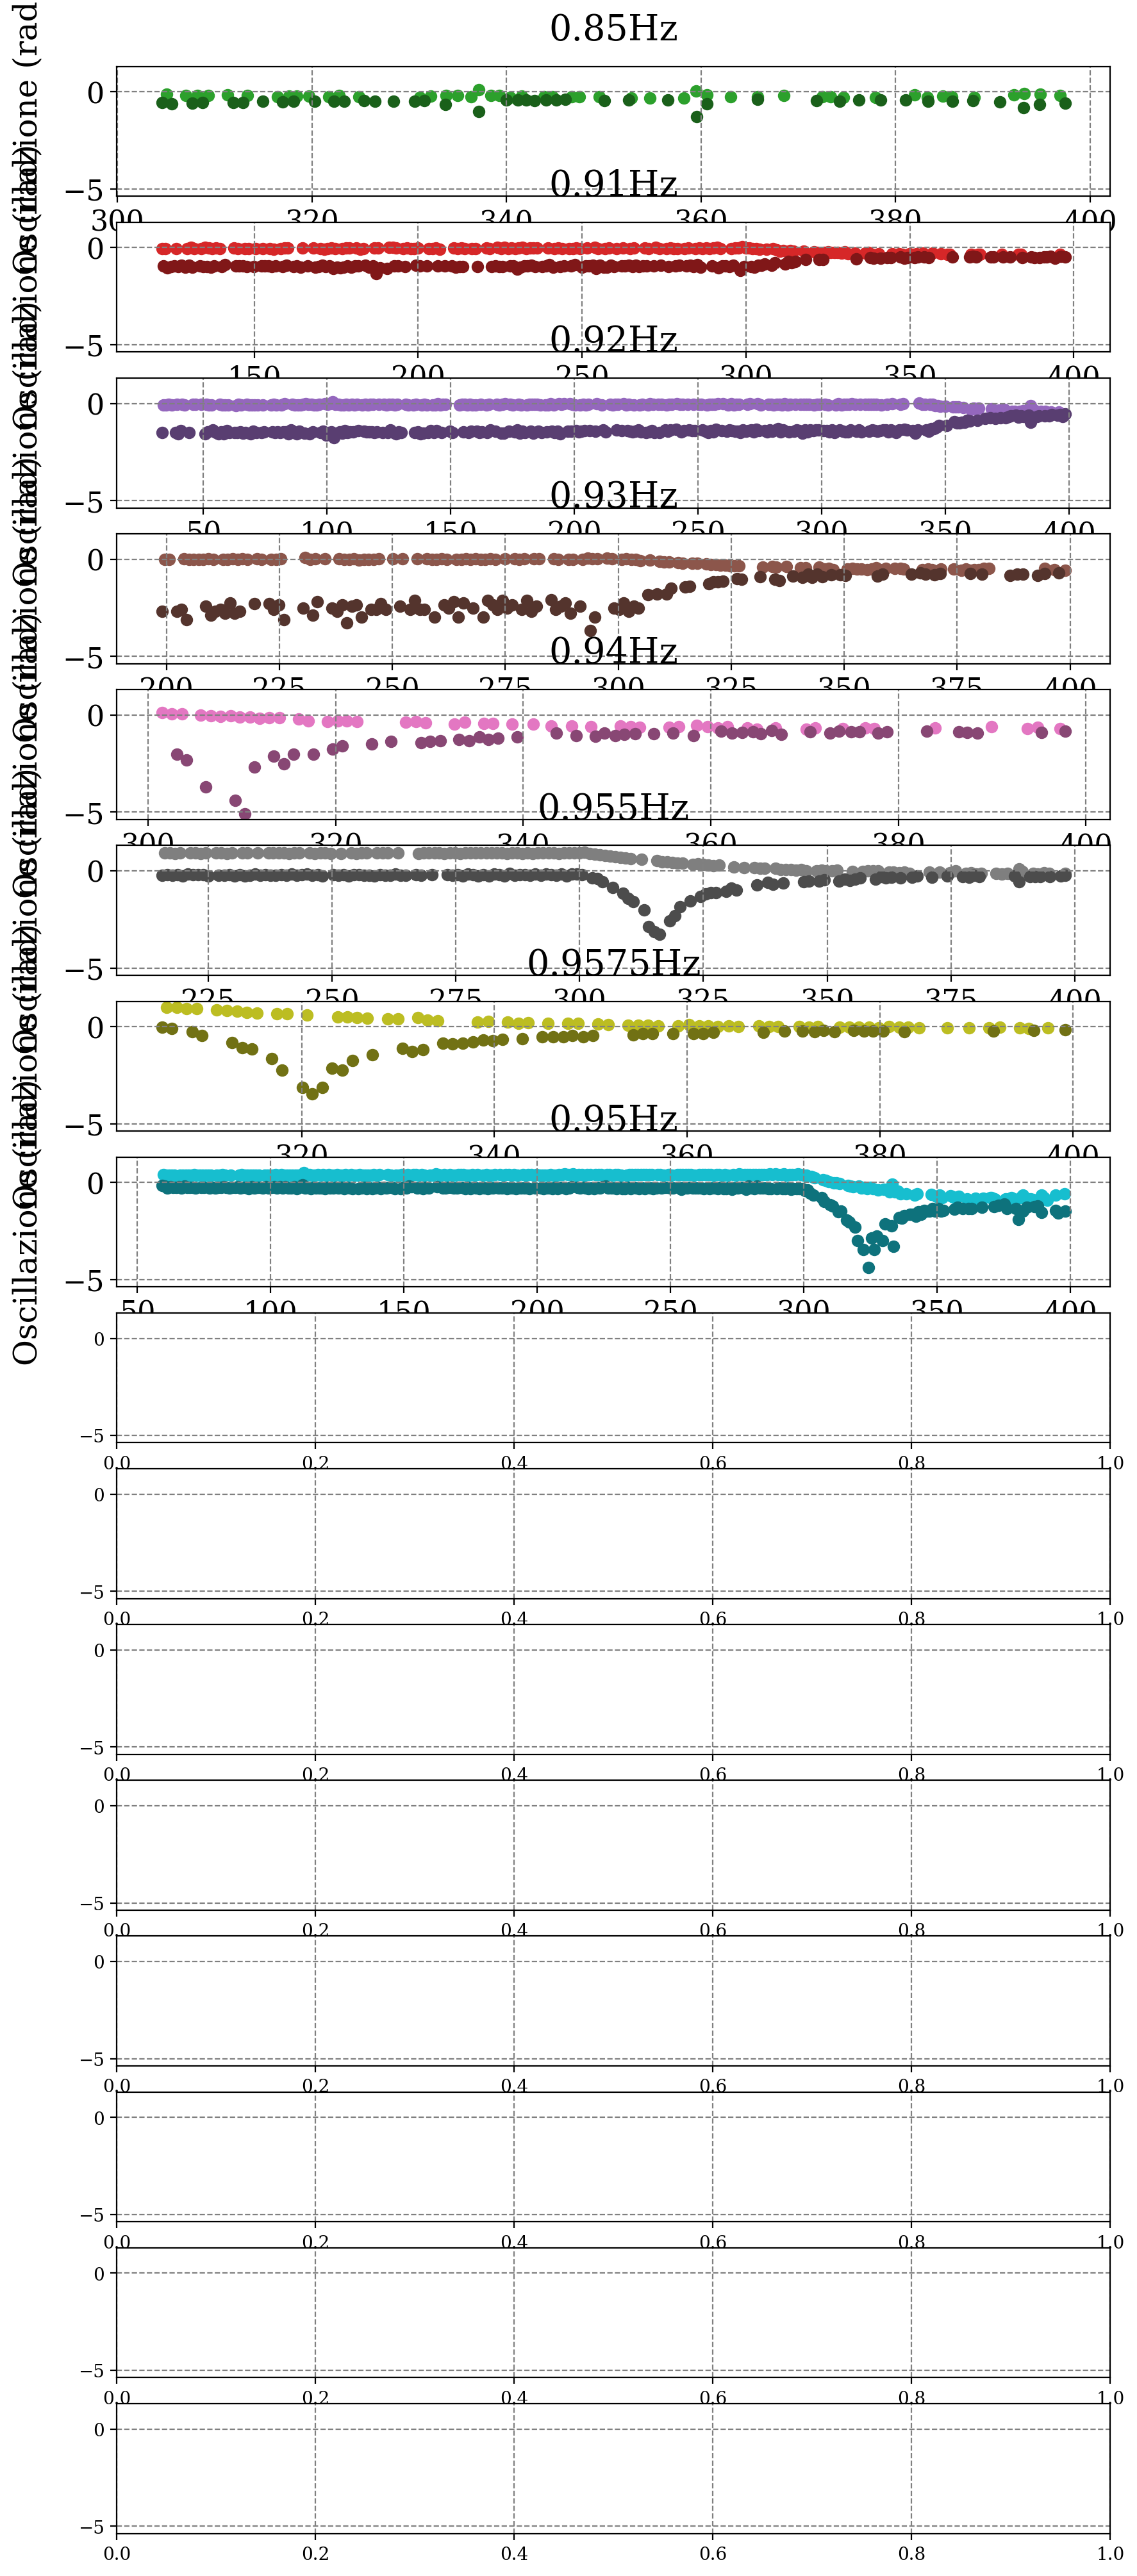

In [92]:
tagliati = {}

def esponenziale(x,A,B):
    return A * np.exp(-B * x)

if grafico_controllo_2: fig,axes = plt.subplots(len(input_files), 1, figsize=(10, 25), sharey=True)

for i, serie in enumerate(dati_tagliati.keys()):
    valori = dati_tagliati[serie]["pendolo"] * (2*np.pi)
    tempi = dati_tagliati[serie]["tempo"]
    massimi, massimi_t = [], []
    minimi, minimi_t = [], []

    periodo = 1 / float(str(serie).replace("Hz",""))
    raggio = max(1, int((periodo / 2) * 50))  # almeno 1

    for j, val in enumerate(valori):
        if j < raggio or j > len(valori) - raggio - 1:
            continue
        # Massimi
        if all(val > valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            massimi.append(abs(val))
            massimi_t.append(tempi[j])
        # Minimi
        if all(val < valori[j + k] for k in range(-raggio, raggio + 1) if k != 0):
            minimi.append(abs(val))
            minimi_t.append(tempi[j])

    tagliati[serie] = {
        "tempo_minimi" : pd.Series(minimi_t),
        "minimi" : pd.Series(minimi),
        "tempo_massimi" : pd.Series(massimi_t),
        "massimi" : pd.Series(massimi),
    }

    print(f"Serie {serie}: {len(massimi)} massimi e {len(minimi)} minimi trovati \n Periodo = {periodo:.2f} s \n Intorno = {2 * raggio}")

    # Fit esponenziale per i massimi
    popt_max, pcov_max = curve_fit(esponenziale, massimi_t, massimi)
    perr_max = np.sqrt(np.diag(pcov_max))
    popt_min, pcov_min = curve_fit(esponenziale, minimi_t, minimi)
    perr_min = np.sqrt(np.diag(pcov_min))
    
    if grafico_controllo_2:
        x = np.linspace(min(massimi_t), max(massimi_t), 1000)
        y_max_fit = esponenziale(x, *popt_max)
        y_min_fit = esponenziale(x, *popt_min)
        ax = axes[i]
        colore = next(color_cycle)
        ax.scatter(massimi_t, np.log(massimi), color=colore)
        ax.scatter(minimi_t, np.log(minimi), color=gf.darken(colore))
        #ax.plot(x, y_max_fit, color=colore, linewidth=0.7)
        #ax.plot(x, y_min_fit, color=gf.darken(colore), linewidth=0.7)
        gf.parametri_grafico(ax, f"{serie}", "Tempo (s)", "Oscillazione (rad)")
if grafico_controllo_2: gf.salva_grafico(fig, f"./Images/ConfrontoMassimiSmorzamento.pdf")

In [ ]:
gf.display_dizionario(tagliati)

## 3.3 File Output

In [ ]:
"""for serie in tagliati.keys():
    file_output = f"./Smorzamento/{serie}.csv"
    with open(file_output, 'w') as f:
        # Intestazione opzionale
        f.write("tempo_minimi,minimi,tempo_massimi,massimi\n")
        
        # Estrai le serie
        tm = tagliati[serie]["tempo_minimi"]
        m = tagliati[serie]["minimi"]
        tM = tagliati[serie]["tempo_massimi"]
        M = tagliati[serie]["massimi"]

        for valori in zip(tm, m, tM, M):
            f.write(",".join(map(str, valori)) + "\n")"""

'for serie in tagliati.keys():\n    file_output = f"./Smorzamento/{serie}.csv"\n    with open(file_output, \'w\') as f:\n        # Intestazione opzionale\n        f.write("tempo_minimi,minimi,tempo_massimi,massimi\n")\n        \n        # Estrai le serie\n        tm = tagliati[serie]["tempo_minimi"]\n        m = tagliati[serie]["minimi"]\n        tM = tagliati[serie]["tempo_massimi"]\n        M = tagliati[serie]["massimi"]\n\n        for valori in zip(tm, m, tM, M):\n            f.write(",".join(map(str, valori)) + "\n")'